# 01. Exploratory Data Analysis on Raw EEG Data

This notebook will help us explore the raw EEG recordings, event markers, and trial structure before we build features or train models.

## What we will inspect

- Subject and run structure
- Raw EDF loading
- Event markers and clip mapping
- Basic plots: signals, events, and power spectra

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

try:
    import mne
except ImportError:
    mne = None

# Try multiple strategies to find the root
ROOT = Path.cwd()
print(f'Current working directory: {ROOT}')
print(f'Contents of cwd: {list(ROOT.iterdir())[:5]}...')

# Strategy 1: if data/ doesn't exist in cwd, try parent
if not (ROOT / 'data').exists() and (ROOT.parent / 'data').exists():
    ROOT = ROOT.parent
    print(f'Updated ROOT to parent: {ROOT}')

# Strategy 2: If still no luck, search upward for a folder containing data/
if not (ROOT / 'data').exists():
    for parent in ROOT.parents:
        if (parent / 'data').exists():
            ROOT = parent
            print(f'Found data/ in ancestor: {ROOT}')
            break

DATA_DIR = ROOT / 'data'
SUBJECT_DIR = DATA_DIR / 'sub-01' / 'eeg'
MUSIC_DIR = DATA_DIR / 'music'

print('\nFinal paths:')
print(f'ROOT: {ROOT}')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')
print(f'SUBJECT_DIR exists: {SUBJECT_DIR.exists()}')
print(f'MUSIC_DIR exists: {MUSIC_DIR.exists()}')

if SUBJECT_DIR.exists():
    edf_path = SUBJECT_DIR / 'sub-01_task-run2_eeg.edf'
    print(f'EDF file exists: {edf_path.exists()} ({edf_path})')


Current working directory: /home/trainerblue/Documents/daly-comp-analysis/notebooks
Contents of cwd: [PosixPath('/home/trainerblue/Documents/daly-comp-analysis/notebooks/01_eda_raw_data.ipynb')]...
Updated ROOT to parent: /home/trainerblue/Documents/daly-comp-analysis

Final paths:
ROOT: /home/trainerblue/Documents/daly-comp-analysis
DATA_DIR exists: True
SUBJECT_DIR exists: True
MUSIC_DIR exists: True
EDF file exists: True (/home/trainerblue/Documents/daly-comp-analysis/data/sub-01/eeg/sub-01_task-run2_eeg.edf)


In [9]:
if mne is None:
    print('mne is not installed yet. We will add the environment next.')
else:
    edf_files = sorted(SUBJECT_DIR.glob('*run2_eeg.edf'))
    print('Run-2 EDF files:', edf_files)

    if edf_files:
        raw = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)
        print(raw)
        display(raw.info)

Run-2 EDF files: [PosixPath('/home/trainerblue/Documents/daly-comp-analysis/data/sub-01/eeg/sub-01_task-run2_eeg.edf')]
<RawEDF | sub-01_task-run2_eeg.edf, 19 x 574000 (574.0 s), ~19 KiB, data not loaded>


/tmp/ipykernel_108043/969199889.py:8: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

,onset,duration,trial_type
0,2.449,20,263
1,2.689,20,786
2,2.817,20,257
3,3.713,20,257
4,5.689,20,788
5,5.689,20,362
6,21.361,20,257
7,21.690,20,1092
8,22.290,20,805
9,22.290,20,903


Unique event codes in run 2: ['1092', '257', '259', '263', '32768', '33568', '33571', '33574', '33575', '362', '413', '435', '440', '460', '463', '466', '476', '633', '657', '786']
Run-2 EDF files: [PosixPath('/home/trainerblue/Documents/daly-comp-analysis/data/sub-01/eeg/sub-01_task-run2_eeg.edf')]
<RawEDF | sub-01_task-run2_eeg.edf, 19 x 574000 (574.0 s), ~19 KiB, data not loaded>


/tmp/ipykernel_108043/2502572934.py:16: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)


<Info | 8 non-empty values
 bads: []
 ch_names: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

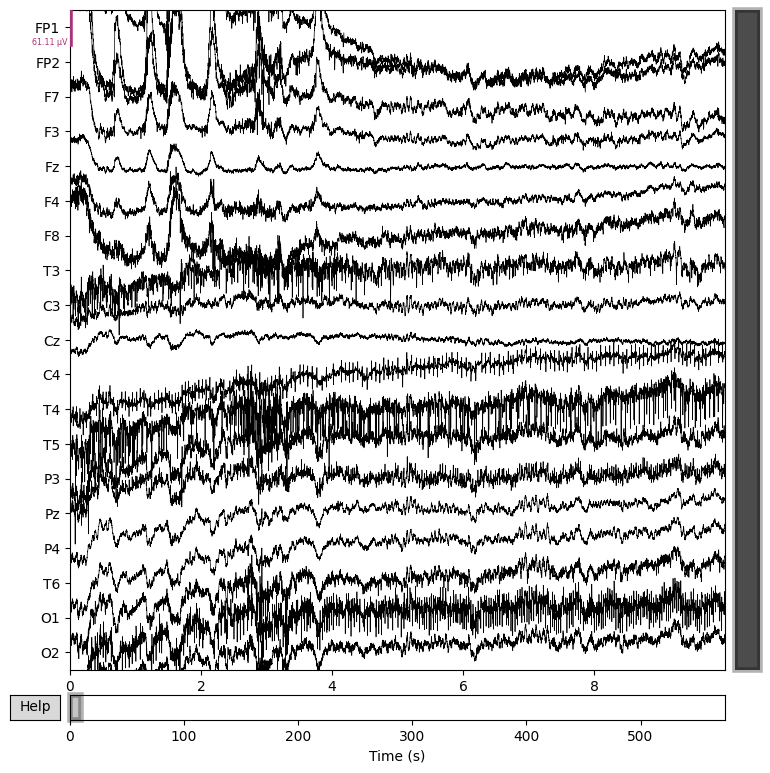

In [10]:
events_path = SUBJECT_DIR / 'sub-01_task-run2_events.tsv'
if events_path.exists():
    events_df = pd.read_csv(events_path, sep='\t')
    display(events_df.head(10))
    print('Unique event codes in run 2:', sorted(events_df['trial_type'].astype(str).unique())[:20])
else:
    print('Events file not found:', events_path)

if mne is None:
    print('mne is not installed yet. We will use this notebook after the environment is ready.')
else:
    edf_files = sorted(SUBJECT_DIR.glob('*run2_eeg.edf'))
    print('Run-2 EDF files:', edf_files)

    if edf_files:
        raw = mne.io.read_raw_edf(edf_files[0], preload=False, verbose=False)
        print(raw)
        display(raw.info)

        raw.plot(duration=10, n_channels=19, scalings='auto', title='sub-01 run-2 raw EEG (first 10s)', show=True)